In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/hey_productos.csv")

In [ ]:
df.describe()

,limite_credito,saldo_actual,utilizacion_pct,tasa_interes_anual,plazo_meses,monto_mensualidad
count,14317.000000,35159.000000,14317.000000,18791.000000,4550.000000,4550.000000
mean,89630.928267,60007.057381,0.432751,29.116338,23.067692,1990.703200
std,94668.497000,84090.727992,0.250377,15.483885,13.751438,1683.125761
min,1000.000000,100.940000,0.050100,3.500000,6.000000,36.290000
25%,29000.000000,15596.240000,0.236100,14.655000,12.000000,738.237500
50%,64000.000000,36290.090000,0.370000,31.740000,18.000000,1477.315000
75%,111000.000000,66193.265000,0.576200,41.060000,24.000000,2784.105000
max,494000.000000,499905.570000,1.000000,66.970000,60.000000,11379.420000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38909 entries, 0 to 38908
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   producto_id              38909 non-null  object 
 1   user_id                  38909 non-null  object 
 2   tipo_producto            38909 non-null  object 
 3   fecha_apertura           38909 non-null  object 
 4   estatus                  38909 non-null  object 
 5   limite_credito           14317 non-null  float64
 6   saldo_actual             35159 non-null  float64
 7   utilizacion_pct          14317 non-null  float64
 8   tasa_interes_anual       18791 non-null  float64
 9   plazo_meses              4550 non-null   float64
 10  monto_mensualidad        4550 non-null   float64
 11  fecha_ultimo_movimiento  38909 non-null  object 
 12  es_dato_sintetico        38909 non-null  bool   
dtypes: bool(1), float64(6), object(6)
memory usage: 3.6+ MB


In [ ]:
df.isnull().sum()

,0
producto_id,0
user_id,0
tipo_producto,0
fecha_apertura,0
estatus,0
limite_credito,24592
saldo_actual,3750
utilizacion_pct,24592
tasa_interes_anual,20118
plazo_meses,34359


#Portafolio por producto

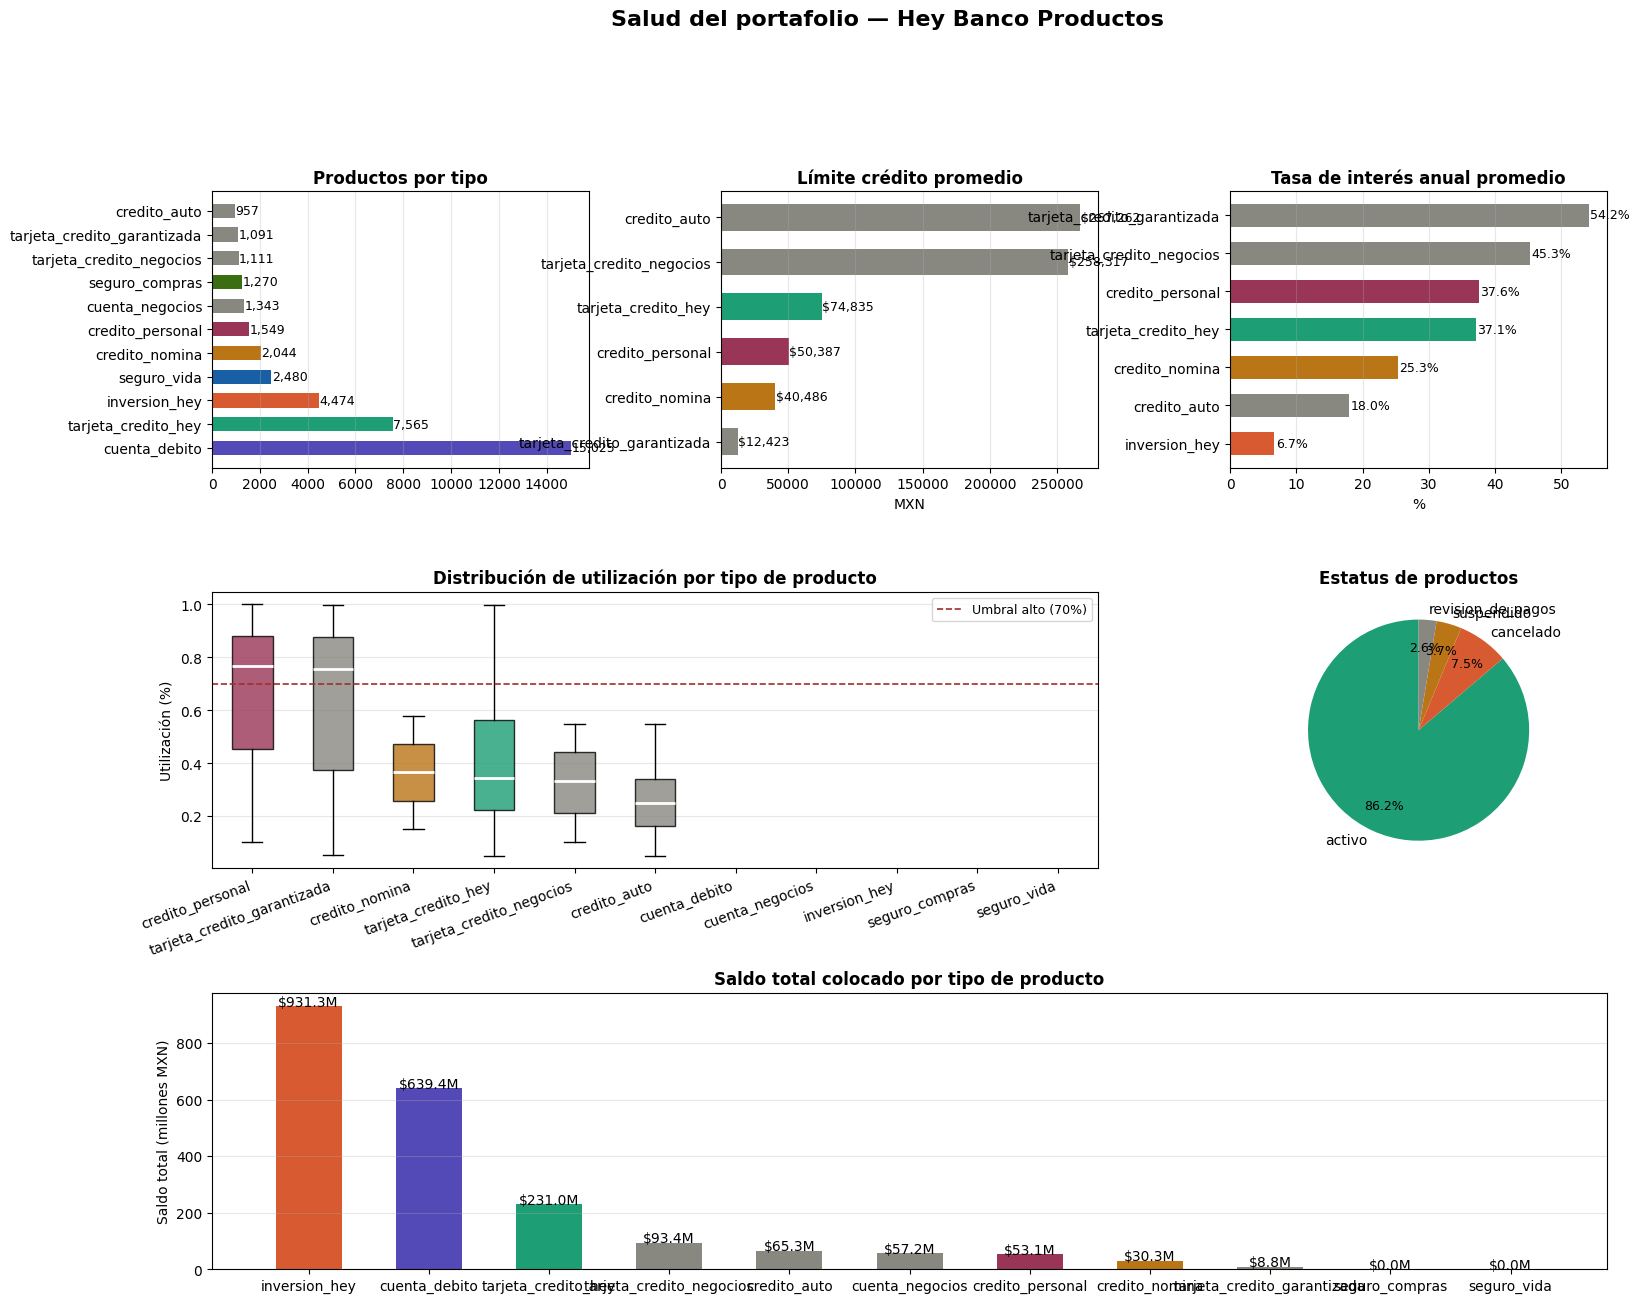

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec


# ── Parsear fechas ────────────────────────────────────────────────────────────
df['fecha_apertura'] = pd.to_datetime(df['fecha_apertura'], errors='coerce')
df['fecha_ultimo_movimiento'] = pd.to_datetime(df['fecha_ultimo_movimiento'], errors='coerce')
df['antiguedad_producto_dias'] = (pd.Timestamp.today() - df['fecha_apertura']).dt.days
df['dias_sin_movimiento'] = (pd.Timestamp.today() - df['fecha_ultimo_movimiento']).dt.days

# ── 1. Distribución y métricas por tipo de producto ──────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, :2])
ax5 = fig.add_subplot(gs[1, 2])
ax6 = fig.add_subplot(gs[2, :])

colores_tipo = {t: c for t, c in zip(
    df['tipo_producto'].unique(),
    ['#534AB7','#1D9E75','#D85A30','#BA7517','#185FA5','#993556','#3B6D11']
)}

# Gráfica 1: Conteo por tipo
conteo = df['tipo_producto'].value_counts()
ax1.barh(conteo.index, conteo.values,
         color=[colores_tipo.get(t,'#888780') for t in conteo.index],
         edgecolor='none', height=0.6)
ax1.set_title('Productos por tipo', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, (idx, val) in enumerate(conteo.items()):
    ax1.text(val+20, i, f'{val:,}', va='center', fontsize=9)

# Gráfica 2: Límite de crédito promedio por tipo
lim_prom = df.groupby('tipo_producto')['limite_credito'].mean().sort_values()
ax2.barh(lim_prom.index, lim_prom.values,
         color=[colores_tipo.get(t,'#888780') for t in lim_prom.index],
         edgecolor='none', height=0.6)
ax2.set_title('Límite crédito promedio', fontweight='bold')
ax2.set_xlabel('MXN')
ax2.grid(axis='x', alpha=0.3)
for i, (idx, val) in enumerate(lim_prom.items()):
    ax2.text(val+500, i, f'${val:,.0f}', va='center', fontsize=9)

# Gráfica 3: Tasa de interés promedio por tipo
tasa_prom = df.groupby('tipo_producto')['tasa_interes_anual'].mean().sort_values()
ax3.barh(tasa_prom.index, tasa_prom.values,
         color=[colores_tipo.get(t,'#888780') for t in tasa_prom.index],
         edgecolor='none', height=0.6)
ax3.set_title('Tasa de interés anual promedio', fontweight='bold')
ax3.set_xlabel('%')
ax3.grid(axis='x', alpha=0.3)
for i, (idx, val) in enumerate(tasa_prom.items()):
    ax3.text(val+0.2, i, f'{val:.1f}%', va='center', fontsize=9)

# Gráfica 4: Utilización promedio por tipo — boxplot
tipos_orden = df.groupby('tipo_producto')['utilizacion_pct'].median().sort_values(ascending=False).index.tolist()
data_box = [df[df['tipo_producto']==t]['utilizacion_pct'].dropna().values for t in tipos_orden]
bp = ax4.boxplot(data_box, vert=True, patch_artist=True, widths=0.5,
                 medianprops=dict(color='white', linewidth=2))
for patch, tipo in zip(bp['boxes'], tipos_orden):
    patch.set_facecolor(colores_tipo.get(tipo, '#888780'))
    patch.set_alpha(0.8)
ax4.set_xticklabels(tipos_orden, rotation=20, ha='right')
ax4.set_ylabel('Utilización (%)')
ax4.set_title('Distribución de utilización por tipo de producto', fontweight='bold')
ax4.axhline(0.7, color='#A32D2D', linestyle='--', linewidth=1.2, label='Umbral alto (70%)')
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)

# Gráfica 5: Estatus (activo/inactivo/etc)
estatus_conteo = df['estatus'].value_counts()
wedges, texts, autotexts = ax5.pie(
    estatus_conteo.values,
    labels=estatus_conteo.index,
    autopct='%1.1f%%',
    colors=['#1D9E75','#D85A30','#BA7517','#888780'][:len(estatus_conteo)],
    startangle=90, pctdistance=0.75
)
for t in autotexts: t.set_fontsize(9)
ax5.set_title('Estatus de productos', fontweight='bold')

# Gráfica 6: Saldo total por tipo de producto (ingreso al banco)
saldo_total = df.groupby('tipo_producto')['saldo_actual'].sum().sort_values(ascending=False)
bars = ax6.bar(saldo_total.index, saldo_total.values/1e6,
               color=[colores_tipo.get(t,'#888780') for t in saldo_total.index],
               edgecolor='none', width=0.55)
ax6.set_ylabel('Saldo total (millones MXN)')
ax6.set_title('Saldo total colocado por tipo de producto', fontweight='bold')
ax6.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, saldo_total.values/1e6):
    ax6.text(bar.get_x()+bar.get_width()/2, val+0.5,
             f'${val:.1f}M', ha='center', fontsize=10)

plt.suptitle('Salud del portafolio — Hey Banco Productos', fontsize=16, fontweight='bold', y=1.01)
plt.show()

#Uso crediticio

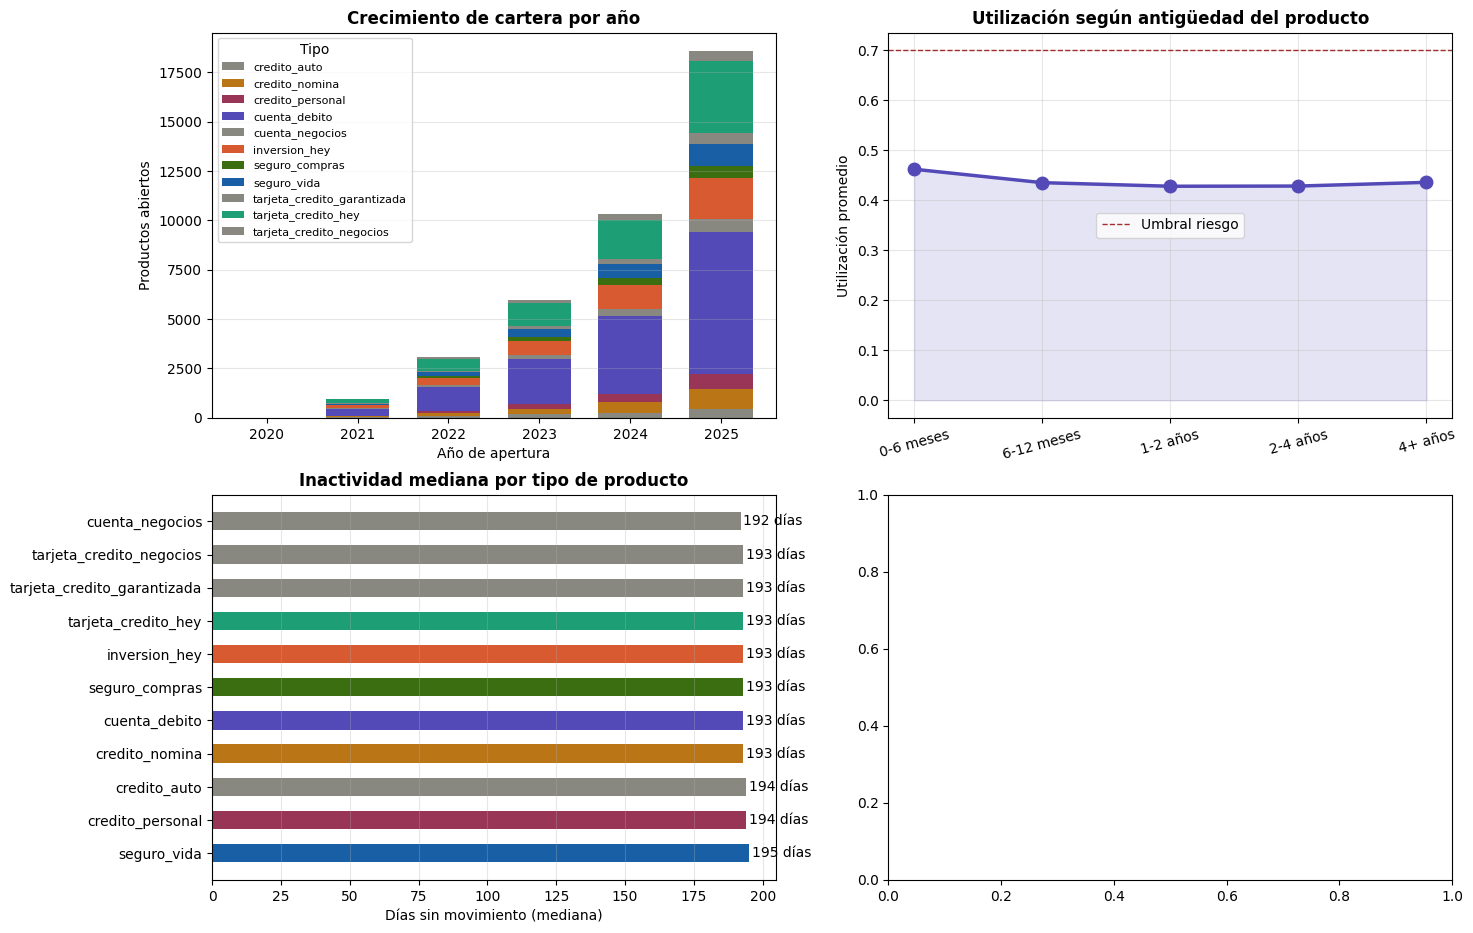

In [ ]:
# ── Análisis de antigüedad y actividad ───────────────────────────────────────
df['anio_apertura'] = df['fecha_apertura'].dt.year
df['mes_apertura']  = df['fecha_apertura'].dt.to_period('M').astype(str)

# Categorías de madurez del producto
def madurez(dias):
    if   dias < 180:  return '0-6 meses'
    elif dias < 365:  return '6-12 meses'
    elif dias < 730:  return '1-2 años'
    elif dias < 1460: return '2-4 años'
    else:             return '4+ años'

df['madurez'] = df['antiguedad_producto_dias'].apply(madurez)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Apertura de productos por año
apertura_anio = df.groupby(['anio_apertura','tipo_producto']).size().unstack(fill_value=0)
apertura_anio.plot(kind='bar', ax=axes[0,0], stacked=True,
                   color=[colores_tipo.get(t,'#888780') for t in apertura_anio.columns],
                   edgecolor='none', width=0.7)
axes[0,0].set_xlabel('Año de apertura')
axes[0,0].set_ylabel('Productos abiertos')
axes[0,0].set_title('Crecimiento de cartera por año', fontweight='bold')
axes[0,0].legend(fontsize=8, title='Tipo')
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].grid(axis='y', alpha=0.3)

# 2. Utilización según madurez del producto
orden_madurez = ['0-6 meses','6-12 meses','1-2 años','2-4 años','4+ años']
util_madurez = df.groupby('madurez')['utilizacion_pct'].mean().reindex(
    [m for m in orden_madurez if m in df['madurez'].values]
)
axes[0,1].plot(util_madurez.index, util_madurez.values,
               'o-', color='#534AB7', linewidth=2.5, markersize=9)
axes[0,1].fill_between(range(len(util_madurez)), util_madurez.values,
                        alpha=0.15, color='#534AB7')
axes[0,1].set_xticks(range(len(util_madurez)))
axes[0,1].set_xticklabels(util_madurez.index, rotation=15)
axes[0,1].set_ylabel('Utilización promedio')
axes[0,1].set_title('Utilización según antigüedad del producto', fontweight='bold')
axes[0,1].axhline(0.70, color='#A32D2D', linestyle='--', linewidth=1, label='Umbral riesgo')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# 3. Días sin movimiento por tipo (inactividad)
inact = df.groupby('tipo_producto')['dias_sin_movimiento'].median().sort_values(ascending=False)
bars = axes[1,0].barh(inact.index, inact.values,
                       color=[colores_tipo.get(t,'#888780') for t in inact.index],
                       edgecolor='none', height=0.55)
axes[1,0].set_xlabel('Días sin movimiento (mediana)')
axes[1,0].set_title('Inactividad mediana por tipo de producto', fontweight='bold')
axes[1,0].grid(axis='x', alpha=0.3)
for bar, val in zip(bars, inact.values):
    axes[1,0].text(val+1, bar.get_y()+bar.get_height()/2,
                   f'{val:.0f} días', va='center', fontsize=10)
